In [ ]:
!pip install -q kagglehub nltk wordcloud

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "clmentbisaillon/fake-and-real-news-dataset"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Path to dataset files: /kaggle/input/fake-and-real-news-dataset


In [ ]:
print(os.listdir(path))

['True.csv', 'Fake.csv']


In [ ]:
fake_path = os.path.join(path, "Fake.csv")
true_path = os.path.join(path, "True.csv")

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

print("Fake news shape:", fake_df.shape)
print("Real news shape:", true_df.shape)

Fake news shape: (23481, 4)
Real news shape: (21417, 4)


In [ ]:
print("Fake News Columns:")
print(fake_df.columns)

print("\nReal News Columns:")
print(true_df.columns)

Fake News Columns:
Index(['title', 'text', 'subject', 'date'], dtype='object')

Real News Columns:
Index(['title', 'text', 'subject', 'date'], dtype='object')


In [ ]:
display(fake_df.head())

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
display(true_df.head())

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
fake_df['label'] = 0
true_df['label'] = 1

In [ ]:
df = pd.concat(
    [fake_df, true_df],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (44898, 5)


In [ ]:
print(
    df['label'].value_counts()
)

label
0    23481
1    21417
Name: count, dtype: int64


In [ ]:
print("Fake news:", (df['label'] == 0).sum())
print("Real news:", (df['label'] == 1).sum())

Fake news: 23481
Real news: 21417


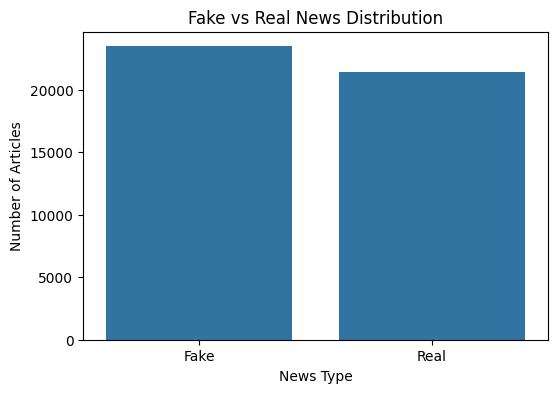

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='label'
)

plt.xticks(
    [0, 1],
    ['Fake', 'Real']
)

plt.title("Fake vs Real News Distribution")
plt.xlabel("News Type")
plt.ylabel("Number of Articles")

plt.show()

In [ ]:
print(
    df[['title', 'text', 'label']].isnull().sum()
)

title    0
text     0
label    0
dtype: int64


In [ ]:
df['content'] = (
    df['title'].fillna('') + ' ' +
    df['text'].fillna('')
)

df[['title', 'text', 'content', 'label']].head()

,title,text,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,Donald Trump Sends Out Embarrassing New Year’...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,Drunk Bragging Trump Staffer Started Russian ...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",Sheriff David Clarke Becomes An Internet Joke...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",Trump Is So Obsessed He Even Has Obama’s Name...,0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,Pope Francis Just Called Out Donald Trump Dur...,0


In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
stop_words = set(
    stopwords.words('english')
)

lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(
        r'<.*?>',
        ' ',
        text
    )

    # Remove URLs
    text = re.sub(
        r'http\S+|www\S+',
        ' ',
        text
    )

    # Keep only letters
    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        text
    )

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

In [ ]:
df['clean_content'] = df['content'].apply(
    clean_text
)

In [ ]:
display(
    df[
        ['content', 'clean_content', 'label']
    ].head()
)

,content,clean_content,label
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump sends embarrassing new year eve m...,0
1,Drunk Bragging Trump Staffer Started Russian ...,drunk bragging trump staffer started russian c...,0
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clarke becomes internet joke thr...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,trump obsessed even obama name coded website i...,0
4,Pope Francis Just Called Out Donald Trump Dur...,pope francis called donald trump christmas spe...,0


In [ ]:
X = df['clean_content']
y = df['label']

print("Number of samples:", len(X))
print("Number of labels:", len(y))

Number of samples: 44898
Number of labels: 44898


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 35918
Testing samples: 8980


In [ ]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

print(
    "Training TF-IDF shape:",
    X_train_tfidf.shape
)

print(
    "Testing TF-IDF shape:",
    X_test_tfidf.shape
)

Training TF-IDF shape: (35918, 50000)
Testing TF-IDF shape: (8980, 50000)


In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = logistic_model.predict(
    X_test_tfidf
)

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

Accuracy: 0.9921
Accuracy: 99.21%


In [ ]:
f1 = f1_score(
    y_test,
    y_pred
)

print(
    f"F1-Score: {f1:.4f}"
)

F1-Score: 0.9917


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'Fake',
            'Real'
        ]
    )
)

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



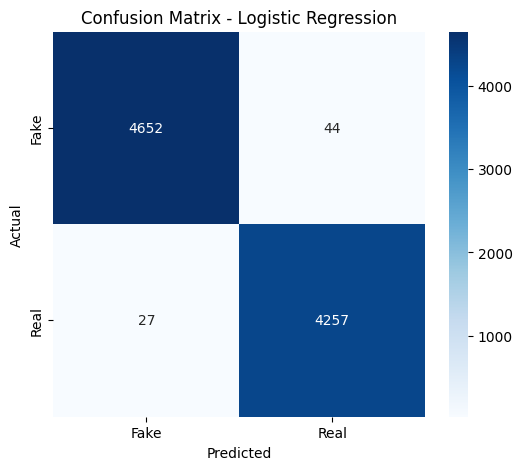

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Fake',
        'Real'
    ],
    yticklabels=[
        'Fake',
        'Real'
    ]
)

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
def predict_news(news):

    cleaned = clean_text(news)

    vector = tfidf.transform(
        [cleaned]
    )

    prediction = logistic_model.predict(
        vector
    )[0]

    if prediction == 0:
        return "Fake"
    else:
        return "Real"

In [ ]:
news_samples = [

    """
    Scientists announced a new discovery that could
    improve renewable energy technology.
    """,

    """
    The government announced new economic measures
    during a meeting with financial officials.
    """,

    """
    A completely fabricated story with an unbelievable
    claim was shared widely online.
    """
]

for news in news_samples:

    print("News:")
    print(news.strip())

    print(
        "Prediction:",
        predict_news(news)
    )

    print("-" * 70)

News:
Scientists announced a new discovery that could
    improve renewable energy technology.
Prediction: Fake
----------------------------------------------------------------------
News:
The government announced new economic measures
    during a meeting with financial officials.
Prediction: Real
----------------------------------------------------------------------
News:
A completely fabricated story with an unbelievable
    claim was shared widely online.
Prediction: Fake
----------------------------------------------------------------------


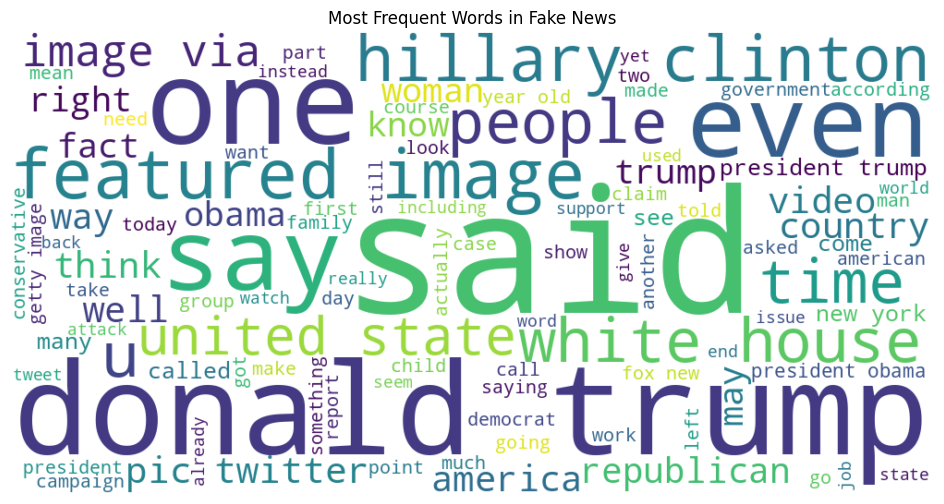

In [ ]:
fake_text = ' '.join(
    df[
        df['label'] == 0
    ]['clean_content']
)

fake_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(fake_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    fake_wordcloud,
    interpolation='bilinear'
)

plt.axis('off')

plt.title(
    "Most Frequent Words in Fake News"
)

plt.show()

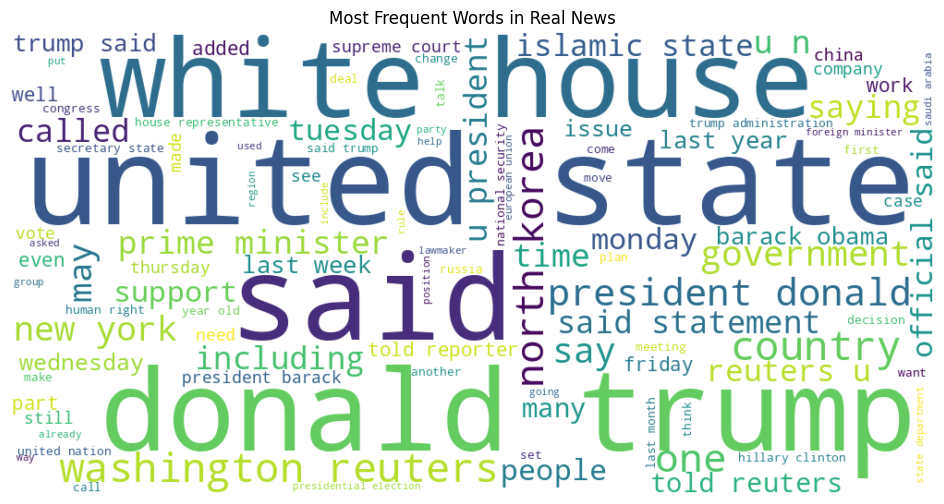

In [ ]:
real_text = ' '.join(
    df[
        df['label'] == 1
    ]['clean_content']
)

real_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(real_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    real_wordcloud,
    interpolation='bilinear'
)

plt.axis('off')

plt.title(
    "Most Frequent Words in Real News"
)

plt.show()

In [ ]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

coefficients = logistic_model.coef_[0]

top_real = np.argsort(coefficients)[-20:][::-1]

top_fake = np.argsort(coefficients)[:20]

print("Top features associated with Real news:\n")

for index in top_real:
    print(
        feature_names[index],
        "->",
        round(coefficients[index], 3)
    )

print("\nTop features associated with Fake news:\n")

for index in top_fake:
    print(
        feature_names[index],
        "->",
        round(coefficients[index], 3)
    )

Top features associated with Real news:

reuters -> 23.017
said -> 12.423
washington reuters -> 9.576
president donald -> 5.373
washington -> 5.273
wednesday -> 4.792
reuters president -> 4.565
tuesday -> 4.31
thursday -> 4.306
minister -> 3.92
friday -> 3.795
nov -> 3.768
monday -> 3.637
said statement -> 3.379
told reuters -> 3.31
representative -> 3.188
spokesman -> 3.105
republican -> 2.919
democratic -> 2.912
president barack -> 2.877

Top features associated with Fake news:

via -> -10.426
video -> -10.26
read -> -6.391
image -> -6.245
obama -> -5.443
president trump -> -5.309
gop -> -4.876
featured image -> -4.825
featured -> -4.809
watch -> -4.719
hillary -> -4.696
america -> -4.633
american -> -4.193
image via -> -4.054
wire -> -3.91
breaking -> -3.856
mr -> -3.814
even -> -3.766
like -> -3.659
com -> -3.632
